# FOGAS on a 3 x 3 Grid with a Wall and Pit

**Objective.** This notebook tests the small-scale FOGAS pipeline when the policy must account for an impassable state, a positive terminal, and an adverse absorbing terminal. Exact planning remains feasible, so oracle and empirical errors can still be distinguished.

**Protocol.** Tabular features are used to compare `Planner`, `FOGASOracleSolver`, and dataset-based `FOGASSolver`. A second experiment replaces the tabular map with a structured state-action representation and evaluates whether aggregation preserves the decisions needed to avoid the pit and reach the goal.

**Role in the empirical study.** This is the final finite validation benchmark before the 10 x 10 coverage experiments. Execute cells in order; saved searches under `data/results/3grid_wall/` are also consumed by `hyperoptimizer_boxplots_summary.ipynb`.

# Problem

**State space.**
The states are encoded as integers
$$\mathcal{X} = {0,1,\dots,8} $$
corresponding to the grid in row-major order (top-left corner to bottom-right corner).
- State $8$ is the terminal goal state and is absorbing.
- State $5$ is the pit state and is absorbing.
- State $4$ is a wall.


**Action space.**
Actions are represented as integers

$$ \mathcal{A} = {0,1,2,3} $$

where $0 =$ Up, $1 =$ Down, $2 =$ Left, $3 =$ Right.

**Transition dynamics.**
Transitions are deterministic. For any state $x$ and action $a$, the state index is first mapped to its grid coordinates $(r,c)$, the action moves the agent one step (unless this would leave the grid), and the result is mapped back to a state index. The goal state $8$ always transitions to itself.
The transition matrix $P$ has shape $(|\mathcal{X}||\mathcal{A}|) \times |\mathcal{X}| = 36 \times 9$, where each row corresponds to a pair $(x,a)$ and contains a one-hot vector indicating the unique next state:

$$P[(x,a),x'] = 1 \quad \text{iff } x' = \text{next\_state}(x,a)$$

and $0$ otherwise.

**Reward model.**
- $r(x,a) = 1$ if x is a goal state.
- $r(x,a) = -1$ if x is the pit state.
- $r(x,a) = -0.01$ otherwise.

**Initial state.**
The initial state is fixed as $x_0 = 0$.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def tensor64(data):
    return torch.as_tensor(data, dtype=torch.float64, device=DEVICE)


def find_root(current_path):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / "src" / "rl_methods").exists() and (parent / "data").exists():
            return parent
    return current_path


PROJECT_ROOT = find_root(Path.cwd())

DATASETS_DIR = PROJECT_ROOT / "data" / "datasets"
RESULTS_DIR = PROJECT_ROOT / "data" / "results" / "3grid_wall"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"

DATASETS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from rl_methods.mdp import DiscreteMDP, Planner
from rl_methods.fogas import (
    FOGASOracleSolver,
    FOGASHyperOptimizer,
    FOGASEvaluator,
    FOGASSolver,
)
from rl_methods.data_collection import DiscreteDataBuffer

# Tabular Features

## Definition

### Description

**Feature Map**

We use a tabular one-hot feature representation over state–action pairs.
Each feature corresponds to a unique \((x,a)\) combination.

The feature map is defined as:
$$
\phi(x,a) \in \mathbb{R}^{36}
$$
with the ordering
$$
(x,a) \;\longrightarrow\; e_{\,x \cdot |\mathcal{A}| + a}
\quad |\mathcal{A}| = 4
$$

**Reward Weights**

The reward function is linear in the features:
$$
r(x,a) = \phi(x,a)^\top \omega.
$$

The weight vector $\omega \in \mathbb{R}^{36}$ is defined as:
$$
\omega_i =
\begin{cases}
1 & \text{if } i \in \{8\cdot 4,\, 8\cdot 4 + 1,\, 8\cdot 4 + 2,\, 8\cdot 4 + 3\}, \\
-1 & \text{if } i \in \{5\cdot 4,\, 5\cdot 4 + 1,\, 5\cdot 4 + 2,\, 5\cdot 4 + 3\}, \\
-0.01 & \text{otherwise}.
\end{cases}
$$

**Transition Weights**

For each $x' \in \mathcal{X}$,
$$
\psi(x')_i =
\begin{cases}
1 & \text{if } i = 4x + a \text{ and } x' = \text{next\_state}(x,a), \\
0 & \text{otherwise}.
\end{cases}
$$

Equivalently, stacking $\psi(x')$ for all $x'$ recovers the tabular
transition matrix
$$
P \in \mathbb{R}^{36 \times 9}
$$
where each row $(x,a)$ contains a single 1 at the column corresponding
to $\text{next\_state}(x,a)$.

The terminal goal state $x = 8$ and pit state $x = 5$ is absorbing, so for all actions $a$,
$$
\text{next\_state}(8,a) = 8 \; \; \; \text{next\_state}(5,a) = 5
$$
And the state 4 is a wall.


## Testing

In [2]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)
N = len(states)
A = len(actions)
gamma = 0.9

x_0 = 0
dataset_path = str(DATASETS_DIR / "3grid_wall.csv")

goal = 8
pit = 5
wall = 4

step_cost = -0.1
goal_reward = 1.0
pit_reward = -1.0


def phi(x, a):
    vec = torch.zeros(N * A, dtype=torch.float64)
    vec[int(x) * A + int(a)] = 1.0
    return vec


omega = torch.full((N * A,), step_cost, dtype=torch.float64)
omega[goal * A : goal * A + A] = goal_reward
omega[pit * A : pit * A + A] = pit_reward


def to_rc(s):
    return divmod(int(s), 3)


def to_s(r, c):
    return r * 3 + c


def next_state(s, a):
    s = int(s)
    a = int(a)

    if s == goal or s == pit:
        return s

    r, c = to_rc(s)

    if a == 0:      # Up
        r2, c2 = max(0, r - 1), c
    elif a == 1:    # Down
        r2, c2 = min(2, r + 1), c
    elif a == 2:    # Left
        r2, c2 = r, max(0, c - 1)
    elif a == 3:    # Right
        r2, c2 = r, min(2, c + 1)
    else:
        raise ValueError(f"Unknown action: {a}")

    sp = to_s(r2, c2)

    if sp == wall:
        return s

    return sp


def transition_fn(s, a):
    probs = torch.zeros(N, dtype=torch.float64)
    probs[next_state(s, a)] = 1.0
    return probs


mdp = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x_0,
    omega=omega,
    phi=phi,
    transition_fn=transition_fn,
    terminal_states=[goal, pit],
)

planner = Planner(mdp, mode="deterministic")

### Oracle

In [3]:
solver = FOGASOracleSolver(
    planner=planner,
    phi=phi,
    cov_matrix="identity",
    print_params=True,
    T=2000,
    seed=SEED,
    device=DEVICE,
)

evaluator = FOGASEvaluator(
    solver=solver,
    mdp=mdp,
    planner=planner,
)

optimizer = FOGASHyperOptimizer(
    solver=solver,
    evaluator=evaluator,
    metric="average_return",
    metric_kwargs={
        "policy_mode": "solver",
        "num_trajectories": 10,
        "max_steps": 20,
        "seed": SEED,
        "terminal_states": [goal, pit],
        "maximize": True,
    },
    seed=SEED,
)


================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           10000000
Feature norm bound R:     1.0000
Num states N:             9
Num actions A:            4
Feature dim d:            36
Discount γ:               0.9
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      9255128.526390366
T (iterations):                2000   (overridden → 2000)

FOGAS Hyperparameters
---------------------
alpha:                        0.000621
rho:                            6.158327
eta:                            0.000012
D_theta:                    18.973666
beta (ridge):             0.000014
D_pi (derived):           23.548200




In [5]:
summary = optimizer.optimize(
    mode="grid",
    parameters=("eta", "rho", "alpha", "D_theta"),
    values={
        "alpha": [6e-4, 1e-3, 1e-2, 1e-1, 1],
        "eta": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
        "rho": [1e-2, 1e-1, 1.0, 10.0, 100.0],
        "D_theta": [
            0.01, 0.1, 0.5, 1.0, 5.0,
            10.0, 20.0,
        ],
    },
    num_runs=1,
    plot=False,
    print_summary=True,
    progress=True,
    results_output=RESULTS_DIR / "oracle.csv",
)

eta_star = summary["best_params"]["eta"]
rho_star = summary["best_params"]["rho"]
alpha_star = summary["best_params"]["alpha"]
D_theta_star = summary["best_params"]["D_theta"]

FOGAS hyperopt:   0%|          | 0/875 [00:00<?, ?candidate/s]


=== FOGAS Hyperparameter Optimization ===
Metric: average_return
Mode: grid
Parameters: ('eta', 'rho', 'alpha', 'D_theta')
Evaluated candidates: 875
Best metric: 0.3439
Best params: alpha=1.0000e-02, rho=1.0000e-02, eta=1.0000e-03, T=2000, D_theta=1.0000e+01, D_pi=2.0000e+02

Top 5 candidates:
1. metric=0.3439 | stage=grid | alpha=1.0000e-02, rho=1.0000e-02, eta=1.0000e-03, T=2000, D_theta=1.0000e+01, D_pi=2.0000e+02
2. metric=0.3439 | stage=grid | alpha=1.0000e-02, rho=1.0000e-02, eta=1.0000e-03, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+02
3. metric=0.3439 | stage=grid | alpha=1.0000e-02, rho=1.0000e-01, eta=1.0000e-03, T=2000, D_theta=1.0000e+01, D_pi=2.0000e+02
4. metric=0.3439 | stage=grid | alpha=1.0000e-02, rho=1.0000e-01, eta=1.0000e-03, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+02
5. metric=0.3439 | stage=grid | alpha=1.0000e-02, rho=1.0000e+00, eta=1.0000e-03, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+02


<Axes: title={'center': 'Solver avg reward by D theta'}, xlabel='D theta', ylabel='Solver avg reward'>

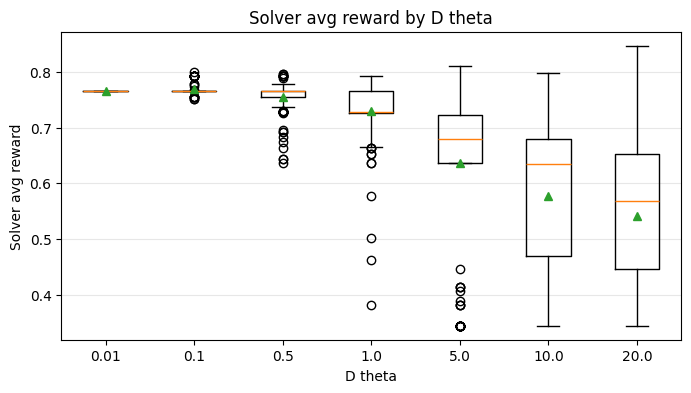

In [6]:
FOGASHyperOptimizer.plot_saved_boxplot(
    csv_path=RESULTS_DIR / "oracle.csv",
    variable="D_theta",
    metric_column="metric",
    variable_label="D theta",
    metric_label="Solver avg reward",
)

In [7]:
solver.run(alpha=alpha_star, eta=eta_star, rho=rho_star, D_theta=D_theta_star, T = 2000, tqdm_print=True)
evaluator.compare_value_functions()

reward_comparison = evaluator.average_return(
    policy_mode="solver",
    num_trajectories=10,
    max_steps=5,
    seed=SEED,
    compare_with_optimal=True,
)

print("Solver average return:", reward_comparison["policy"])
print("Optimal average return:", reward_comparison["optimal"])
print("Gap:", reward_comparison["difference"])

FOGAS Oracle:   0%|                                                                  | 0/2000 [00:00<?, ?it/s]

FOGAS Oracle: 100%|██████████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 898.46it/s]


========== VALUE FUNCTION COMPARISON ==========

Policy mode: solver

State-wise V comparison:
State 0: V*(x) =  6.217100 | V^pi(x) =  6.206124 | delta = -1.097621e-02
State 1: V*(x) =  5.495390 | V^pi(x) =  5.444970 | delta = -5.042025e-02
State 2: V*(x) =  4.845851 | V^pi(x) =  4.689602 | delta = -1.562488e-01
State 3: V*(x) =  7.019000 | V^pi(x) =  7.017412 | delta = -1.588265e-03
State 4: V*(x) =  7.910000 | V^pi(x) =  7.909996 | delta = -3.818338e-06
State 5: V*(x) = -10.000000 | V^pi(x) = -10.000000 | delta =  0.000000e+00
State 6: V*(x) =  7.910000 | V^pi(x) =  7.909873 | delta = -1.272310e-04
State 7: V*(x) =  8.900000 | V^pi(x) =  8.899996 | delta = -4.220963e-06
State 8: V*(x) =  10.000000 | V^pi(x) =  10.000000 | delta =  0.000000e+00

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  5.495390 | Q^pi(x,a) =  5.485511 | delta = -9.878586e-03
(x=0, a=1): Q*(x,a) =  6.217100 | Q^pi(x,a) =  6.215671 | delta = -1.429438e-03
(x=0, a=2): Q*(x,a) =  5.495390 | Q^pi(x,a) =  5.485511

### Dataset Collection

In [10]:
collector = DiscreteDataBuffer(
    mdp=mdp,
    max_steps=20,
    terminal_states=[goal, pit],
    reset_probs={"x0": 1.0},
    seed=SEED,
)

df = collector.collect(
    policy="random",
    n_steps=500,
    save_path=dataset_path,
    verbose=True,
)

Collected 500 transitions over 32 episodes.
Policy distribution:
policy_id
0    1.0
Name: proportion, dtype: float64
Reset mode distribution:
reset_mode
x0    1.0
Name: proportion, dtype: float64
Saved FOGAS dataset to /shared/home/mauro.diaz/work/FOGAS/data/datasets/3grid_wall.csv


### Empirical

In [8]:
solver_e = FOGASSolver(
    mdp=mdp,
    phi=phi,
    csv_path=dataset_path,
    print_params=True,
    seed=SEED,
    device=DEVICE,
    T = 2000,
)

evaluator_e = FOGASEvaluator(
    solver=solver_e,
    mdp=mdp,
    planner=planner,
)

optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    evaluator=evaluator_e,
    metric="average_return",
    metric_kwargs={
        "policy_mode": "solver",
        "num_trajectories": 10,
        "max_steps": 20,
        "seed": SEED,
        "terminal_states": [goal, pit],
        "maximize": True,
    },
    seed=SEED,
)


Device: cuda
Dataset: /shared/home/mauro.diaz/work/FOGAS/data/datasets/3grid_wall.csv (n=500)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           500
Feature norm bound R:     1.0000
Num states N:             9
Num actions A:            4
Feature dim d:            36
Discount γ:               0.9
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      462.7564263195183
T (iterations):                2000   (overridden → 2000)

FOGAS Hyperparameters
---------------------
alpha:                        0.000621
rho:                            870.919017
eta:                            0.000012
D_theta:                    18.973666
beta (ridge):             0.000014
D_pi (derived):           23.548200




Trying same optimal hyperparameters found for the oracle.

In [9]:
solver_e.run(
    alpha=alpha_star,
    eta=eta_star,
    rho=rho_star,
    D_theta=D_theta_star,
    tqdm_print=True,
)

evaluator_e.compare_value_functions(policy_mode="solver")

reward_comparison = evaluator_e.average_return(
    policy_mode="solver",
    num_trajectories=10,
    max_steps=20,
    seed=SEED,
    compare_with_optimal=True,
)

print("Solver average return:", reward_comparison["policy"])
print("Optimal average return:", reward_comparison["optimal"])
print("Gap:", reward_comparison["difference"])

FOGAS:   0%|                                                                         | 0/2000 [00:00<?, ?it/s]

FOGAS: 100%|████████████████████████████████████████████████████████████| 2000/2000 [00:01<00:00, 1804.27it/s]



========== VALUE FUNCTION COMPARISON ==========

Policy mode: solver

State-wise V comparison:
State 0: V*(x) =  6.217100 | V^pi(x) =  0.165169 | delta = -6.051931e+00
State 1: V*(x) =  5.495390 | V^pi(x) = -6.402576 | delta = -1.189797e+01
State 2: V*(x) =  4.845851 | V^pi(x) = -8.539420 | delta = -1.338527e+01
State 3: V*(x) =  7.019000 | V^pi(x) =  5.180436 | delta = -1.838564e+00
State 4: V*(x) =  7.910000 | V^pi(x) = -0.742384 | delta = -8.652384e+00
State 5: V*(x) = -10.000000 | V^pi(x) = -10.000000 | delta =  0.000000e+00
State 6: V*(x) =  7.910000 | V^pi(x) =  6.749323 | delta = -1.160677e+00
State 7: V*(x) =  8.900000 | V^pi(x) =  8.367100 | delta = -5.328996e-01
State 8: V*(x) =  10.000000 | V^pi(x) =  10.000000 | delta =  0.000000e+00

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  5.495390 | Q^pi(x,a) =  0.048652 | delta = -5.446738e+00
(x=0, a=1): Q*(x,a) =  6.217100 | Q^pi(x,a) =  4.562392 | delta = -1.654708e+00
(x=0, a=2): Q*(x,a) =  5.495390 | Q^pi(x,a) =  0.048652

In [10]:
summary_e = optimizer_e.optimize(
    mode="grid",
    parameters=("alpha", "eta", "D_theta", "rho"),
    values={
        "alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1],
        "eta": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
        "rho": [1e-2, 1e-1, 1.0, 10.0, 100.0],
        "D_theta": [0.1, 0.5, 1.0, 5.0, 20.0],
    },
    num_runs=1,
    plot=False,
    print_summary=True,
    progress=True,
    results_output= RESULTS_DIR / "empirical_tab.csv"
)

alpha_star_e = summary_e["best_params"]["alpha"]
eta_star_e = summary_e["best_params"]["eta"]
D_theta_star_e = summary_e["best_params"]["D_theta"]
rho_star_e = summary_e["best_params"]["rho"]

FOGAS hyperopt:   0%|          | 0/750 [00:00<?, ?candidate/s]


=== FOGAS Hyperparameter Optimization ===
Metric: average_return
Mode: grid
Parameters: ('alpha', 'eta', 'D_theta', 'rho')
Evaluated candidates: 750
Best metric: 0.271
Best params: alpha=1.0000e-01, rho=1.0000e-02, eta=1.0000e-01, T=2000, D_theta=5.0000e-01, D_pi=1.0000e+02

Top 5 candidates:
1. metric=0.271 | stage=grid | alpha=1.0000e-01, rho=1.0000e-02, eta=1.0000e-01, T=2000, D_theta=5.0000e-01, D_pi=1.0000e+02
2. metric=0.271 | stage=grid | alpha=1.0000e+00, rho=1.0000e-02, eta=1.0000e-03, T=2000, D_theta=5.0000e+00, D_pi=1.0000e+04
3. metric=0.271 | stage=grid | alpha=1.0000e+00, rho=1.0000e-01, eta=1.0000e-03, T=2000, D_theta=5.0000e+00, D_pi=1.0000e+04
4. metric=0.271 | stage=grid | alpha=1.0000e+00, rho=1.0000e-02, eta=1.0000e-02, T=2000, D_theta=1.0000e-01, D_pi=2.0000e+02
5. metric=0.271 | stage=grid | alpha=1.0000e+00, rho=1.0000e-02, eta=1.0000e-02, T=2000, D_theta=5.0000e+00, D_pi=1.0000e+04


<Axes: title={'center': 'Solver avg reward by D theta'}, xlabel='D theta', ylabel='Solver avg reward'>

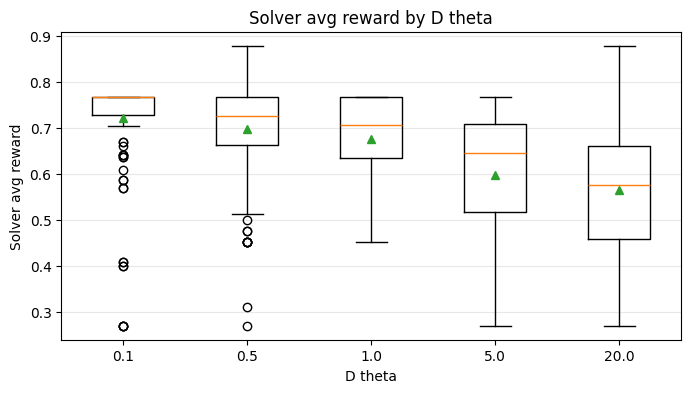

In [11]:
FOGASHyperOptimizer.plot_saved_boxplot(
    csv_path=RESULTS_DIR / "empirical_tab.csv",
    variable="D_theta",
    metric_column="metric",
    variable_label="D theta",
    metric_label="Solver avg reward",
)

In [16]:
solver_e.run(
    alpha=alpha_star_e,
    eta=eta_star_e,
    D_theta=D_theta_star_e,
    rho=rho_star_e,
    tqdm_print=True,
)

evaluator_e.compare_value_functions(policy_mode="solver")

reward_comparison_e = evaluator_e.average_return(
    policy_mode="solver",
    num_trajectories=10,
    max_steps=20,
    seed=SEED,
    compare_with_optimal=True,
)

print("Solver average return:", reward_comparison_e["policy"])
print("Optimal average return:", reward_comparison_e["optimal"])
print("Gap:", reward_comparison_e["difference"])

FOGAS: 100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:01<00:00, 1866.91it/s]



========== VALUE FUNCTION COMPARISON ==========

Policy mode: solver

State-wise V comparison:
State 0: V*(x) =  6.217100 | V^pi(x) =  6.156175 | delta = -6.092505e-02
State 1: V*(x) =  5.495390 | V^pi(x) = -8.251455 | delta = -1.374685e+01
State 2: V*(x) =  4.845851 | V^pi(x) = -9.057172 | delta = -1.390302e+01
State 3: V*(x) =  7.019000 | V^pi(x) =  6.951349 | delta = -6.765090e-02
State 4: V*(x) =  7.910000 | V^pi(x) = -0.658816 | delta = -8.568816e+00
State 5: V*(x) = -10.000000 | V^pi(x) = -10.000000 | delta =  0.000000e+00
State 6: V*(x) =  7.910000 | V^pi(x) =  7.834832 | delta = -7.516766e-02
State 7: V*(x) =  8.900000 | V^pi(x) =  8.816480 | delta = -8.351963e-02
State 8: V*(x) =  10.000000 | V^pi(x) =  10.000000 | delta =  0.000000e+00

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  5.495390 | Q^pi(x,a) =  5.440557 | delta = -5.483254e-02
(x=0, a=1): Q*(x,a) =  6.217100 | Q^pi(x,a) =  6.156214 | delta = -6.088581e-02
(x=0, a=2): Q*(x,a) =  5.495390 | Q^pi(x,a) =  5.440557

It converged after an optimization trying all type of permutation between the three parameters relative to the order. Also heuristically choosing lower bounds to search and the most important thing: (INCREASING THE T FROM 200 TO 1000) but keeping $n =200$ that is much faster.

# State aggregation

## Testing

In [12]:
# -----------------------------
# Problem definition
# -----------------------------
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)
N = len(states)
A = len(actions)
gamma = 0.9

x_0 = 0
dataset_path = str(DATASETS_DIR / "3grid_wall.csv")

goal = 8
pit = 5
wall = 4

step_cost = -0.01
goal_reward = 1.0
pit_reward = -1.0


# -----------------------------
# Helpers
# -----------------------------
def to_rc(s):
    return divmod(int(s), 3)


def to_s(r, c):
    return int(r) * 3 + int(c)


# -----------------------------
# Deterministic dynamics
# -----------------------------
def next_state(s, a):
    s = int(s)
    a = int(a)

    if s == goal or s == pit:
        return s

    r, c = to_rc(s)

    if a == 0:      # Up
        r2, c2 = max(0, r - 1), c
    elif a == 1:    # Down
        r2, c2 = min(2, r + 1), c
    elif a == 2:    # Left
        r2, c2 = r, max(0, c - 1)
    elif a == 3:    # Right
        r2, c2 = r, min(2, c + 1)
    else:
        raise ValueError(f"Invalid action: {a}")

    sp = to_s(r2, c2)

    if sp == wall:
        return s

    return sp


def transition_fn(s, a):
    probs = torch.zeros(N, dtype=torch.float64)
    probs[next_state(s, a)] = 1.0
    return probs


# -----------------------------
# Features
# action: [1, dr, dc] in R^3
# state: exact 3x3 one-hot in R^9
# phi(x,a) = kron(phi_action(a), phi_state(x)) in R^27
# -----------------------------
d_state = 9
d_action = 3
d_feat = d_state * d_action


def phi_state(x):
    r, c = to_rc(x)
    row = torch.zeros(3, dtype=torch.float64)
    col = torch.zeros(3, dtype=torch.float64)
    row[r] = 1.0
    col[c] = 1.0
    return torch.kron(row, col)


def phi_action(a):
    a = int(a)

    if a == 0:      # Up
        dr, dc = -1.0, 0.0
    elif a == 1:    # Down
        dr, dc = 1.0, 0.0
    elif a == 2:    # Left
        dr, dc = 0.0, -1.0
    elif a == 3:    # Right
        dr, dc = 0.0, 1.0
    else:
        raise ValueError(f"Invalid action: {a}")

    return torch.tensor([1.0, dr, dc], dtype=torch.float64)


def phi(x, a):
    return torch.kron(phi_action(a), phi_state(x))


# -----------------------------
# Exact omega for state-only reward
# r(x,a) = r_state(x)
# Stored in the action-bias block omega[:9].
# -----------------------------
r_state = torch.full((N,), step_cost, dtype=torch.float64)
r_state[goal] = goal_reward
r_state[pit] = pit_reward

omega = torch.zeros(d_feat, dtype=torch.float64)
omega[:d_state] = r_state


mdp = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x_0,
    omega=omega,
    phi=phi,
    transition_fn=transition_fn,
    terminal_states=[goal, pit],
)

planner = Planner(mdp, mode="deterministic")

### Empirical

In [13]:
solver_e = FOGASSolver(
    mdp=mdp,
    phi=phi,
    csv_path=dataset_path,
    print_params=True,
    seed=SEED,
    device=DEVICE,
    T = 2000,
)

evaluator_e = FOGASEvaluator(
    solver=solver_e,
    mdp=mdp,
    planner=planner,
)

optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    evaluator=evaluator_e,
    metric="average_return",
    metric_kwargs={
        "policy_mode": "solver",
        "num_trajectories": 10,
        "max_steps": 20,
        "seed": SEED,
        "terminal_states": [goal],
        "maximize": True,
    },
    seed=SEED,
)


Device: cuda
Dataset: /shared/home/mauro.diaz/work/FOGAS/data/datasets/3grid_wall.csv (n=500)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           500
Feature norm bound R:     1.4142
Num states N:             9
Num actions A:            4
Feature dim d:            27
Discount γ:               0.9
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      925.512852639037
T (iterations):                2000   (overridden → 2000)

FOGAS Hyperparameters
---------------------
alpha:                        0.000507
rho:                            653.189262
eta:                            0.000011
D_theta:                    16.431677
beta (ridge):             0.000037
D_pi (derived):           16.651092




In [14]:
summary_e = optimizer_e.optimize(
    mode="grid",
    parameters=("alpha", "eta", "D_theta", "rho"),
    values={
        "alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1],
        "eta": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
        "rho": [1e-2, 1e-1, 1.0, 10.0, 100.0],
        "D_theta": [0.1, 0.5, 1.0, 5.0, 20.0],
    },
    num_runs=1,
    plot=False,
    print_summary=True,
    progress=True,
    results_output= RESULTS_DIR / "empirical_agg.csv"
)

alpha_star_e = summary_e["best_params"]["alpha"]
eta_star_e = summary_e["best_params"]["eta"]
D_theta_star_e = summary_e["best_params"]["D_theta"]
rho_star_e = summary_e["best_params"]["rho"]

FOGAS hyperopt:   0%|          | 0/750 [00:00<?, ?candidate/s]


=== FOGAS Hyperparameter Optimization ===
Metric: average_return
Mode: grid
Parameters: ('alpha', 'eta', 'D_theta', 'rho')
Evaluated candidates: 750
Best metric: 0.03439
Best params: alpha=1.0000e+00, rho=1.0000e-02, eta=1.0000e-02, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+04

Top 5 candidates:
1. metric=0.03439 | stage=grid | alpha=1.0000e+00, rho=1.0000e-02, eta=1.0000e-02, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+04
2. metric=0.03439 | stage=grid | alpha=1.0000e+00, rho=1.0000e-01, eta=1.0000e-02, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+04
3. metric=0.0356366 | stage=grid | alpha=1.0000e+00, rho=1.0000e-02, eta=1.0000e-01, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+04
4. metric=0.0413958 | stage=grid | alpha=1.0000e+00, rho=1.0000e-02, eta=1.0000e-02, T=2000, D_theta=5.0000e+00, D_pi=1.0000e+04
5. metric=0.0435453 | stage=grid | alpha=1.0000e+00, rho=1.0000e+01, eta=1.0000e-01, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+04


<Axes: title={'center': 'Solver avg reward by D theta'}, xlabel='D theta', ylabel='Solver avg reward'>

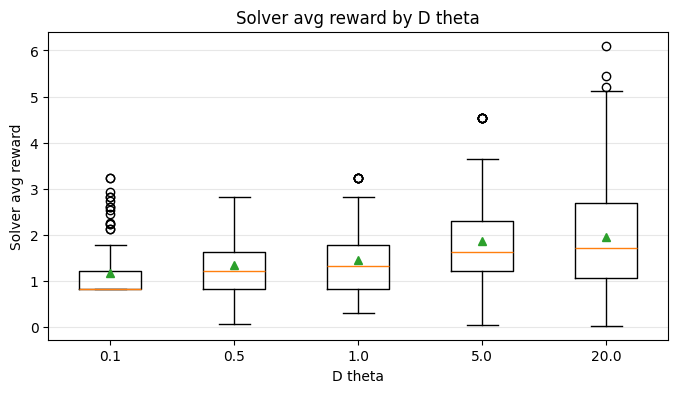

In [15]:
FOGASHyperOptimizer.plot_saved_boxplot(
    csv_path=RESULTS_DIR / "empirical_agg.csv",
    variable="D_theta",
    metric_column="metric",
    variable_label="D theta",
    metric_label="Solver avg reward",
)

In [16]:
solver_e.run(
    alpha=alpha_star_e,
    eta=eta_star_e,
    D_theta=D_theta_star_e,
    rho=rho_star_e,
    tqdm_print=True,
)

evaluator_e.compare_value_functions(policy_mode="solver")

reward_comparison_e = evaluator_e.average_return(
    policy_mode="solver",
    num_trajectories=10,
    max_steps=20,
    seed=SEED,
    compare_with_optimal=True,
)

print("Solver average return:", reward_comparison_e["policy"])
print("Optimal average return:", reward_comparison_e["optimal"])
print("Gap:", reward_comparison_e["difference"])

FOGAS:   0%|                                                                         | 0/2000 [00:00<?, ?it/s]

FOGAS: 100%|████████████████████████████████████████████████████████████| 2000/2000 [00:01<00:00, 1875.61it/s]



========== VALUE FUNCTION COMPARISON ==========

Policy mode: solver

State-wise V comparison:
State 0: V*(x) =  6.526610 | V^pi(x) =  6.496981 | delta = -2.962869e-02
State 1: V*(x) =  5.863949 | V^pi(x) = -0.100000 | delta = -5.963949e+00
State 2: V*(x) =  5.267554 | V^pi(x) = -0.100000 | delta = -5.367554e+00
State 3: V*(x) =  7.262900 | V^pi(x) =  7.229979 | delta = -3.292077e-02
State 4: V*(x) =  8.081000 | V^pi(x) =  1.366995 | delta = -6.714005e+00
State 5: V*(x) = -10.000000 | V^pi(x) = -10.000000 | delta =  0.000000e+00
State 6: V*(x) =  8.081000 | V^pi(x) =  8.044421 | delta = -3.657863e-02
State 7: V*(x) =  8.990000 | V^pi(x) =  8.990000 | delta =  0.000000e+00
State 8: V*(x) =  10.000000 | V^pi(x) =  10.000000 | delta =  0.000000e+00

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  5.863949 | Q^pi(x,a) =  5.837283 | delta = -2.666582e-02
(x=0, a=1): Q*(x,a) =  6.526610 | Q^pi(x,a) =  6.496981 | delta = -2.962869e-02
(x=0, a=2): Q*(x,a) =  5.863949 | Q^pi(x,a) =  5.837283